### Imports and hardware checks

In [1]:
using Pkg
Pkg.activate("../")
Base.Threads.nthreads()

  Activating project at `c:\Users\serge\OhMyU1`


4

In [2]:
using Random, Plots, StatsBase, JLD2, OMEinsum, PyCall, SparseArrays, LinearAlgebra
using OhMyU1
using OhMyU1: ChargeIndex, U1MPS
using OhMyU1: sample_feasible_lp, sample_feasible_lp!, compute_link_charges, compute_site_charges, compute_indices, init_u1_mps, 
orthogonalize!, normalize!, TrainParams, boltzman_probability, train_nondeg!, sample_nondeg_parallel!, cost, u1_norm
using OhMyU1: diversify!, update_index!, graph_dist, random_bilinear_form, random_assignment_vector, fill_assignment_vectors_parallel!,
pick_best_samples, assignment_matrix, generate_random_matrix_vector, SolverParams, graph_dist_global, solve, get_mps, build_mps_from_feasible_samples,
OptimizationProblem, assert_feasible_lp, fill_assignment_vectors!
using Statistics, LaTeXStrings


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


### Data generator

In [ ]:
function generate_random_matrix_vector_sparse(m, N, r; density=0.1)

    maskA = rand(m, N) .< density
    maskb = rand(m)    .< density

    vals = vcat(-r:-1, 1:r)

    A = zeros(Int, m, N)
    b = zeros(Int, m)

    A[maskA] .= rand(vals, sum(maskA))
    b[maskb] .= rand(vals, sum(maskb))

    return A, b
end

generate_random_matrix_vector_sparse (generic function with 1 method)

### Solvers

In [35]:
function solve_random_problems(t_size::Vector{Int}, res_dict::Dict{Int, Dict{String, Vector{Float64}}}; 
    N::Int=50, m::Int=5, r::Int=1, time_limit::Float64=5.0, num_random_problems::Int=20)

    for t in t_size_arr
        res_dict[t] = Dict("with_diff_num" => Float64[], "no_diff_num" => Float64[],
        "with_diff_time" => Float64[], "no_diff_time" => Float64[])
    end

    i = 1
    while i <= num_random_problems
        A, b = generate_random_matrix_vector(m, N, r)

        if !assert_feasible_lp(A, b, time_limit)  # time_limit seconds time limit for feasibility check
            println("Generated infeasible LP, skipping...")
            continue
        end

        @save "../data/random_problems_n_$(N)_m_$(m)_r_$(r)/problem_$(i).jld2" A b
        println("\n=== Iteration ", i, " ===")
        i += 1


        optimization_problem = OptimizationProblem(A=A, b=b, cost_function=x->1.0, name="Random LP $(i)")
        T = sample_feasible_lp(A, b, maximum(t_size_arr), time_limit=time_limit)

        for n in t_size_arr
            t1 = @elapsed begin
            mps = build_mps_from_feasible_samples(optimization_problem, T[:, 1:n], 1, false)
            orthogonalize!(mps)
            end
            push!(res_dict[n]["no_diff_time"], t1)
            push!(res_dict[n]["no_diff_num"], u1_norm(mps) ^ 2)
            println("Before diversification: ", u1_norm(mps) ^ 2)
            t2 = @elapsed begin
            diversify!(mps)
            end
            mps.ort_center = 0
            orthogonalize!(mps)
            push!(res_dict[n]["with_diff_time"], t2 + t1)
            push!(res_dict[n]["with_diff_num"], u1_norm(mps) ^ 2)
            println("After diversification: ", u1_norm(mps) ^ 2, "\n")
        end

        @save "../data/random_problems_n_$(N)_m_$(m)_r_$(r)/res.jld2" res_dict

    end
    return res_dict
end


solve_random_problems (generic function with 1 method)

In [4]:
function solve_different_assignment(n_vector::Vector{Int64}, res_dict::Dict{Float64, Dict{String, Vector{Float64}}};
    time_limit::Float64=5.0, T_size::Int=500, num_random_problems::Int=10)

    for n in n_vector
        d = 1 / n
        res_dict[d] = Dict("with_diff_num" => Float64[], "no_diff_num" => Float64[], 
        "with_diff_time" => Float64[], "no_diff_time" => Float64[])
    end

    for n in n_vector
        d = 1 / n
        println("Solving for n = $n (density = $d)")
        A = assignment_matrix(n)
        b = ones(Int, 2 * n)
        optimization_problem = OptimizationProblem(A=A, b=b, cost_function=x->1.0, name="Assignment problem with n = $n")

        for _ in 1:num_random_problems
            T = zeros(Int, n ^ 2, T_size)  ### Memory allocation;
            fill_assignment_vectors_parallel!(T, n)
            t1 = @elapsed begin
            mps = build_mps_from_feasible_samples(optimization_problem, T, 1, false)
            orthogonalize!(mps)
            end
            push!(res_dict[d]["no_diff_time"], t1)
            push!(res_dict[d]["no_diff_num"], u1_norm(mps) ^ 2)
            println("Before diversification: ", u1_norm(mps) ^ 2)
            t2 = @elapsed begin
            diversify!(mps)
            end
            mps.ort_center = 0
            orthogonalize!(mps)
            push!(res_dict[d]["with_diff_time"], t2 + t1)
            push!(res_dict[d]["with_diff_num"], u1_norm(mps) ^ 2)
            println("After diversification: ", u1_norm(mps) ^ 2, "\n")

            @save "../data/assignment_results/res_sparse_assign.jld2" res_dict

        end
    end
    return res_dict
end

solve_different_assignment (generic function with 1 method)

In [5]:
function solve_with_different_sparsity(density::Vector{Float64}, res_dict::Dict{Float64, Dict{String, Vector{Float64}}}; 
    N::Int=75, m::Int=10, r::Int=1, time_limit::Float64=8.0, num_random_problems::Int=10, T_size::Int=500)

    for d in density
        res_dict[d] = Dict("with_diff_num" => Float64[], "no_diff_num" => Float64[],
        "with_diff_time" => Float64[], "no_diff_time" => Float64[])
    end


    for d in density
        i = 1
        println("\n=== Density ", d, " ===")
        while i <= num_random_problems
            A, b = generate_random_matrix_vector_sparse(m, N, r; density=d)

            if !assert_feasible_lp(A, b, time_limit)  # time_limit seconds time limit for feasibility check
                println("Generated infeasible LP, skipping...")
                continue
            end

            @save "../data/random_problems_n_$(N)_m_$(m)_r_$(r)/problem_density_$(d)_$(i).jld2" A b
            i += 1


            optimization_problem = OptimizationProblem(A=A, b=b, cost_function=x->1.0, name="Random sparse LP $(i)")
            T = sample_feasible_lp(A, b, T_size, time_limit=time_limit)
            @assert size(T, 2) > 0.95 * T_size "Not enough feasible samples generated for density $d, problem $i. Got $(size(T, 2)) samples."

            t1 = @elapsed begin
            mps = build_mps_from_feasible_samples(optimization_problem, T, 1, false)
            orthogonalize!(mps)
            end
            push!(res_dict[d]["no_diff_time"], t1)
            push!(res_dict[d]["no_diff_num"], u1_norm(mps) ^ 2)
            println("Before diversification: ", u1_norm(mps) ^ 2)
            t2 = @elapsed begin
            diversify!(mps)
            end
            mps.ort_center = 0
            orthogonalize!(mps)
            push!(res_dict[d]["with_diff_time"], t2 + t1)
            push!(res_dict[d]["with_diff_num"], u1_norm(mps) ^ 2)
            println("After diversification: ", u1_norm(mps) ^ 2, "\n")

            @save "../data/random_problems_n_$(N)_m_$(m)_r_$(r)/res_sparse.jld2" res_dict

        end
    end
    return res_dict
end

solve_with_different_sparsity (generic function with 1 method)

### Plotters & Fitters

#### Common

In [40]:
function linear_fit(x, y, sem)
    σ = sem
    w = 1 ./ (σ .^ 2) 
    A = [ones(length(x)) x]
    W = Diagonal(w)
    β = (A' * W * A) \ (A' * W * y)

    b, a = β 
    return a, b
end

function linear_fit_no_intercept(x, y, sem)
    w = 1 ./ (sem .^ 2)
    A = x
    W = Diagonal(w)
    a = (A' * W * A) \ (A' * W * y)

    return a
end

linear_fit_no_intercept (generic function with 1 method)

In [39]:
# --- FIT FUNCTION y = A * x^b ---
    function powerlaw_fit(x, y, sem)
        X = log.(x)
        Y = log.(y)
        σY = sem ./ y
        w = 1 ./ (σY .^ 2)

        W = Diagonal(w)
        A = [ones(length(X)) X]
        β = (A' * W * A) \ (A' * W * Y)

        lnA, b = β
        return exp(lnA), b
    end

powerlaw_fit (generic function with 1 method)

#### Random (with different density)

In [4]:
function fit_num_samples_on_density(res_dict::Dict{Float64, Dict{String, Vector{Float64}}}; num_skip::Int=0, plot_here::Bool=false, m::Int=5)
    density_arr = sort(collect(keys(res_dict)))
    mean_with = [mean(res_dict[t]["with_diff_num"]) for t in density_arr]
    mean_no   = [mean(res_dict[t]["no_diff_num"])   for t in density_arr]

    sem_with = [std(res_dict[t]["with_diff_num"]) / sqrt(length(res_dict[t]["with_diff_num"])) for t in density_arr]
    sem_no   = [std(res_dict[t]["no_diff_num"])   / sqrt(length(res_dict[t]["no_diff_num"]))   for t in density_arr]

    sparsity_arr = 1 .- density_arr
    y_ticks_range = 4:2:20
    y_tick_vals = 10 .^ (y_ticks_range)

    if plot_here
        initial_plot_function = plot!
    else
        initial_plot_function = plot
    end

    # --- GRAPH ---
    initial_plot_function(
        sparsity_arr, mean_with;
        yerror = sem_with,
        label = "EELS (m = $(m))",
        lw = 2,
        marker = :circle,
        xlabel = "Sparsity of the constraints matrix",
        ylabel = "Number of samples in MPS",
        xscale = :log10,
        yscale = :log10,
        # title = "Num samples in MPS, |T|=400",
        xticks = (sparsity_arr, string.(sparsity_arr)),
        yticks = (y_tick_vals, [latexstring("10^{$i}") for i in y_ticks_range]),
        ylims = (1e2, 1e24),
    )

    plot!(
        sparsity_arr, mean_no;
        yerror = sem_no,
        label = "Method (ii) (m = $(m))",
        lw = 2,
        marker = :diamond,
        xscale = :log10,
        yscale = :log10,
        xticks = (sparsity_arr, string.(sparsity_arr)),
        legend = :topleft,
        yticks = (y_tick_vals, [latexstring("10^{$i}") for i in y_ticks_range])
    )
end

fit_num_samples_on_density (generic function with 1 method)

In [ ]:
using Statistics

function plot_ratio_mean(res_dict, plot_here=true, m=5)
    density_arr = sort(collect(keys(res_dict)))
    
    ratios_per_t = [res_dict[t]["with_diff_num"] ./ res_dict[t]["no_diff_num"] for t in density_arr]
    mean_ratios = [mean(r) for r in ratios_per_t]
    
    sem_ratios = [std(r) / sqrt(length(r)) for r in ratios_per_t]

    sparsity_arr = 1 .- density_arr
    plot_func = plot_here ? plot! : plot

    y_ticks = [1, 2, 10, 50, 100, 300]

    # --- GRAPH ---
    plot_func(
        sparsity_arr, mean_ratios;
        yerror = sem_ratios,
        label = "Mean Ratio (EELS / Method(ii)), m=$m",
        lw = 2,
        marker = :circle,
        xlabel = "Sparsity of the constraints matrix",
        ylabel = "Mean of (EELS / Method(ii)) samples",
        xscale = :log10,
        yscale = :log10,
        # title = "Num samples ratio, |T|=400",
        xticks = (sparsity_arr, string.(sparsity_arr)),
        ylims=(0.8, 1000),
        yticks=(y_ticks, string.(y_ticks))
    )
end


plot_ratio_mean (generic function with 3 methods)

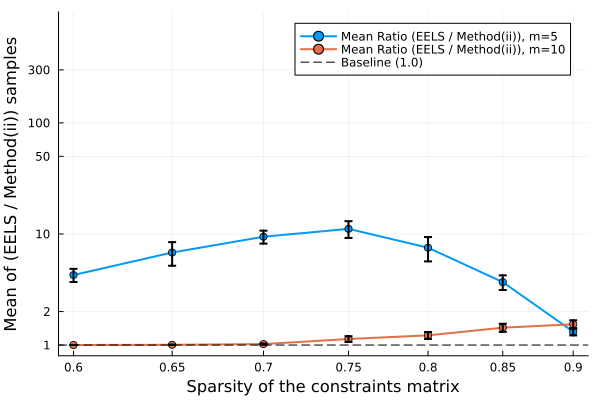

In [15]:
res1 = load("../data/random_problems_n_75_m_5_r_2/res_sparse.jld2", "res_dict")
res2 = load("../data/random_problems_n_75_m_10_r_2/res_sparse.jld2", "res_dict")

plot_ratio_mean(res1, false, 5)
plot_ratio_mean(res2, true, 10)
hline!([1.0], linestyle=:dash, color=:black, label="Baseline (1.0)")
plot!(legend_position=:topright)
# plot!(title = "Num samples ratio, |T|=400, r=1")

In [ ]:
savefig("pictures/num_samples_sparse_r2_relative.png")

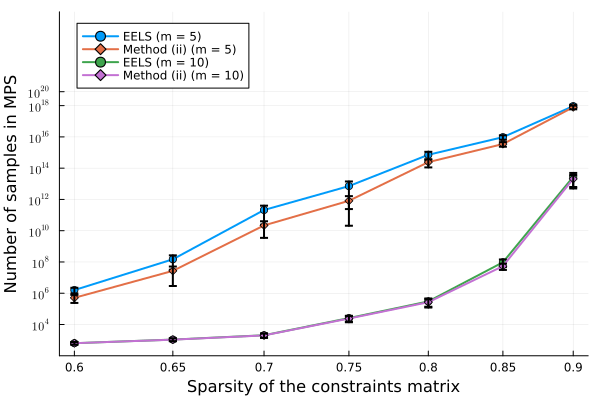

In [ ]:
res1 = load("../data/random_problems_n_75_m_5_r_2/res_sparse.jld2", "res_dict")
fit_num_samples_on_density(res1, m=5)
res2 = load("../data/random_problems_n_75_m_10_r_2/res_sparse.jld2", "res_dict")
fit_num_samples_on_density(res2, plot_here=true, m=10)
# plot!(title="Num samples in MPS, |T|=400, r=1")

In [ ]:
savefig("pictures/Num_samples_sparse_r2.png")

#### Assignment

In [49]:
function plot_ratio_mean_assignment(res_dict, plot_here=true)
    density_arr = sort(collect(keys(res_dict)))
    ratios_per_t = [res_dict[t]["with_diff_num"] ./ res_dict[t]["no_diff_num"] for t in density_arr]

    mean_ratios = [mean(r) for r in ratios_per_t]
    
    sem_ratios = [std(r) / sqrt(length(r)) for r in ratios_per_t]

    sparsity_arr = 1 .- density_arr
    plot_func = plot_here ? plot! : plot
    num_vars = [round(Int, (1 / d) ^ 2 ) for d in density_arr]

    # --- GRAPH ---
    p = plot_func(twinx(),
        num_vars, mean_ratios;
        yerror = sem_ratios,
        label = "Mean Ratio (EELS / Method(ii))",
        lw = 2,
        marker = :circle,
        xlabel = "Number of Variables",
        ylabel = "Mean of (EELS / Method(ii)) samples",
        xscale = :log10,
        yscale = :log10,
        # title = "Number of Constraints",
        # titlefont=11,
        xticks = ([36, 49, 100, 144, 361, 900], string.([36, 49, 100, 144, 361, 900])),
        xlims=(30, 1000),
        ylims=(0.5, 15),
        color=:black,
        yticks=([0.5, 1, 2, 3, 5, 10], string.([0.5, 1, 2, 3, 5, 10])),
        legend=false,
    )
    # plot!(legend_position=(0.15, 0.8))

    # y1 = 12
    # tick_positions2 = [36, 49, 100, 144, 361, 900]
    # tick_labels2 = string.([12, 14, 20, 24, 38, 60])

    # for (xi, lbl) in zip(tick_positions2, tick_labels2)
        
    #     plot!([xi, xi], [y1, y1*0.9], color=:black, label=false, lw=1)
    #     annotate!(xi, y1*0.8, text(lbl, 8))
    # end

    # plot!([30, 1000], [y1, y1], color=:black, lw=1, label=false)
end

plot_ratio_mean_assignment (generic function with 2 methods)

In [56]:
function fit_assignment(res_dict::Dict{Float64, Dict{String, Vector{Float64}}}; num_skip::Int=0, plot_here::Bool=false)
    density_arr = sort(collect(keys(res_dict)))
    mean_with = [mean(res_dict[t]["with_diff_num"]) for t in density_arr]
    mean_no   = [mean(res_dict[t]["no_diff_num"])   for t in density_arr]

    sem_with = [std(res_dict[t]["with_diff_num"]) / sqrt(length(res_dict[t]["with_diff_num"])) for t in density_arr]
    sem_no   = [std(res_dict[t]["no_diff_num"])   / sqrt(length(res_dict[t]["no_diff_num"]))   for t in density_arr]

    sparsity_arr = 1 .- density_arr
    num_vars = [round(Int, (1 / d) ^ 2 ) for d in density_arr]
    num_constraints = [round(Int, 2 * (1 / d)) for d in density_arr]

    y_tick_vals = [1, 1000, 1000000, 1000000000, 1000000000000]

    if plot_here
        initial_plot_function = plot!
    else
        initial_plot_function = plot
    end

    # --- active indices ---
    active_idx = 1:length(sparsity_arr) - num_skip

    # x_data = sparsity_arr[active_idx]
    x_data = num_vars[active_idx]
    y_with = mean_with[active_idx]
    y_no   = mean_no[active_idx]

    sem_with = sem_with[active_idx]
    sem_no   = sem_no[active_idx]

    # --- GRAPH ---
    p = initial_plot_function(
        x_data, y_with;
        yerror = sem_with,
        label = "EELS",
        lw = 2,
        marker = :circle,
        xlabel = "Number of Variables",
        ylabel = "Number of samples in TT",
        xscale = :log10,
        yscale = :log10,
        title = "Number of Constraints",
        titlefont=11,
        xticks = ([36, 49, 100, 144, 361, 900], string.([36, 49, 100, 144, 361, 900])),
        yticks = (y_tick_vals, string.(["1e0", "1e3", "1e6", "1e9", "1e12"])),
    )

    plot!(
        x_data, y_no;
        yerror = sem_no,
        label = "Method (ii)",
        lw = 2,
        marker = :diamond,
        xscale = :log10,
        yscale = :log10,
        legend=:none,
        legend_position=(0.05, 0.5),
        ylims=(1e2 * 0.5 * 0.000000001, 1e13),
        xlims=(30, 1000)
    )

    plot!([], [], label="Mean Ratio", color=:black, marker=:circle, lw=2)

    plot!(legend_position=(0.15, 0.8))
    # plot!(legend_position=:bottomright)

    y1 = 1e13
    tick_positions2 = [36, 49, 100, 144, 361, 900]
    tick_labels2 = string.([12, 14, 20, 24, 38, 60])

    for (xi, lbl) in zip(tick_positions2, tick_labels2)
        plot!([xi, xi], [y1, y1*0.5], color=:black, label=false, lw=1)
        annotate!(xi, y1*0.2, text(lbl, 8))
    end

    plot!([30, 1000], [y1, y1], color=:black, lw=1, label=false)

end

fit_assignment (generic function with 1 method)

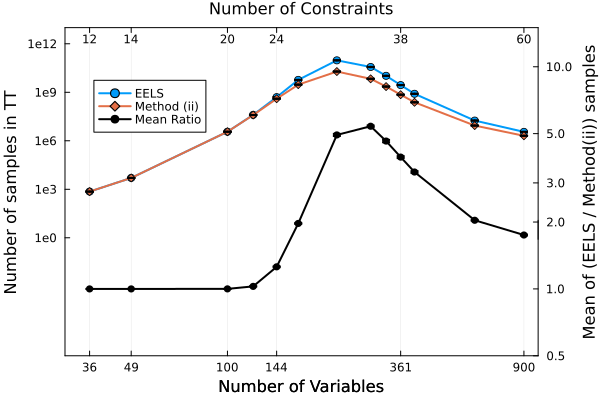

In [61]:
res_dict_small = load("../data/assignment_results/res_sparse_assign_T_10000.jld2", "res_dict")
res_dict_large = load("../data/assignment_results/res_sparse_assign_large_points_T_10000.jld2", "res_dict")

res_dict_small_rel = deepcopy(res_dict_small)
res_dict_large_rel = deepcopy(res_dict_large)

res_dict = merge(res_dict_small, res_dict_large)
res_dict_rel = merge(res_dict_small_rel, res_dict_large_rel)


fit_assignment(res_dict, plot_here=false)
plot!([1000, 1000], [0.8, 12], color=:black, label=false)
plot_ratio_mean_assignment(res_dict_rel, true)

# plot!([n ^ 2 for n in [6, 7, 8, 9, 10, 11, 12, 13, 14]], [factorial(n) for n in [6, 7, 8, 9, 10, 11, 12, 13, 14]], label="n!", lw=2, linestyle=:dash, color=:green)

In [62]:
savefig("pictures/assignment_10000_merged.pdf")

"c:\\Users\\serge\\OhMyU1\\examples\\pictures\\assignment_10000_merged.pdf"

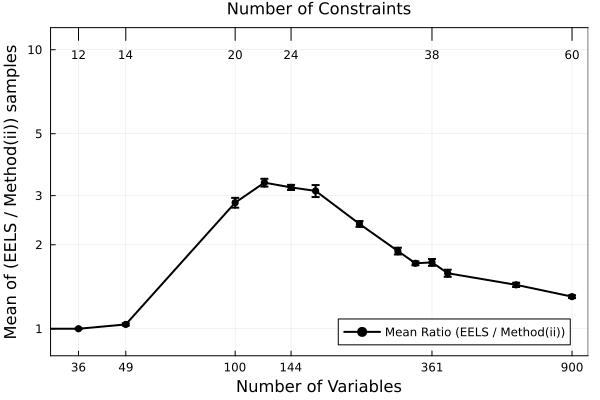

In [ ]:
res_dict_small = load("../data/assignment_results/res_sparse_assign_T_400.jld2", "res_dict")
# res_dict_large = load("../data/assignment_results/res_sparse_assign_large_points_T_10000.jld2", "res_dict")
plot_ratio_mean_assignment(res_dict_small, false)
plot!([1000, 1000], [0.8, 12], color=:black, label=false)

In [ ]:
savefig("pictures/assignment_400_ratio.png")

#### Num samples in TT and time (EELS vs Method (ii))

In [ ]:
function fit_and_plot_num_samples(res_dict::Dict{Int, Dict{String, Vector{Float64}}}; num_skip::Int=2)
    t_size_arr = sort(collect(keys(res_dict)))
    mean_with = [mean(res_dict[t]["with_diff_num"]) for t in t_size_arr]
    mean_no   = [mean(res_dict[t]["no_diff_num"])   for t in t_size_arr]

    sem_with = [std(res_dict[t]["with_diff_num"]) / sqrt(length(res_dict[t]["with_diff_num"])) for t in t_size_arr]
    sem_no   = [std(res_dict[t]["no_diff_num"])   / sqrt(length(res_dict[t]["no_diff_num"]))   for t in t_size_arr]

    # --- FIT indices ---
    fit_idx = (num_skip + 1):length(t_size_arr)

    x_fit_data = t_size_arr[fit_idx]
    y_with_fit = mean_with[fit_idx]
    y_no_fit   = mean_no[fit_idx]

    sem_with_fit = sem_with[fit_idx]
    sem_no_fit   = sem_no[fit_idx]

    # --- FITS ---
    A_with, b_with = powerlaw_fit(x_fit_data, y_with_fit, sem_with_fit)
    A_no,   b_no   = powerlaw_fit(x_fit_data, y_no_fit,   sem_no_fit)

    # --- GRAPH ---
    plot(
        t_size_arr, mean_with;
        yerror = sem_with,
        label = "EELS",
        lw = 2,
        marker = :circle,
        xlabel = "Training dataset size",
        ylabel = "Number of samples in TT",
        xscale = :log10,
        yscale = :log10,
        legend = :topleft,
    )

    plot!(
        t_size_arr, mean_no;
        yerror = sem_no,
        label = "Method (ii)",
        lw = 2,
        marker = :diamond,
    )

    # --- FITS GRAPHS ---
    x_plot = range(minimum(t_size_arr), maximum(t_size_arr), length=300)

    plot!(
        x_plot, A_with .* x_plot .^ b_with;
        label = "Fit: y = $(round(A_with, digits=8)) * x^$(round(b_with, digits=1))",
        ls = :dash,
        lw = 2,
    )

    plot!(
        x_plot, A_no .* x_plot .^ b_no;
        label = "Fit: y = $(round(A_no, digits=6)) * x^$(round(b_no, digits=1))",
        ls = :dash,
        lw = 2,
    )
end

fit_and_plot_num_samples (generic function with 1 method)

In [45]:
function fit_and_plot_time(res_dict::Dict{Int, Dict{String, Vector{Float64}}}; num_skip::Int=0)
    t_size_arr = sort(collect(keys(res_dict)))
    mean_with = [mean(res_dict[t]["with_diff_time"]) for t in t_size_arr]
    mean_no   = [mean(res_dict[t]["no_diff_time"])   for t in t_size_arr]

    sem_with = [std(res_dict[t]["with_diff_time"]) / sqrt(length(res_dict[t]["with_diff_time"])) for t in t_size_arr]
    sem_no   = [std(res_dict[t]["no_diff_time"])   / sqrt(length(res_dict[t]["no_diff_time"]))   for t in t_size_arr]

    # --- FIT indices ---
    fit_idx = (num_skip + 1):length(t_size_arr)

    x_fit_data = t_size_arr[fit_idx]
    y_with_fit = mean_with[fit_idx]
    y_no_fit   = mean_no[fit_idx]

    sem_with_fit = sem_with[fit_idx]
    sem_no_fit   = sem_no[fit_idx]

    # --- FITS ---
    A_with = linear_fit_no_intercept(x_fit_data, y_with_fit, sem_with_fit)
    A_no   = linear_fit_no_intercept(x_fit_data, y_no_fit,   sem_no_fit)

    # --- GRAPH ---
    plot(
        t_size_arr, mean_with;
        yerror = sem_with,
        label = "EELS",
        lw = 2,
        marker = :circle,
        xlabel = "Training dataset size",
        ylabel = "Runtime, seconds",
        xscale = :log10,
        yscale = :log10,
        # title = "Mean values with SEM and linear fits",
    )

    plot!(
        t_size_arr, mean_no;
        yerror = sem_no,
        label = "Method (ii)",
        lw = 2,
        marker = :diamond,
    )

    # --- FITS GRAPHS ---
    x_plot = range(minimum(t_size_arr), maximum(t_size_arr), length=300)

    plot!(
        x_plot, A_with .* x_plot;
        label = "Fit: y = $(round(A_with, digits=5)) * x",
        ls = :dash,
        lw = 2,
    )

    plot!(
        x_plot, A_no .* x_plot;
        label = "Fit: y = $(round(A_no, digits=5)) * x",
        ls = :dash,
        lw = 2,
    )
end

fit_and_plot_time (generic function with 1 method)

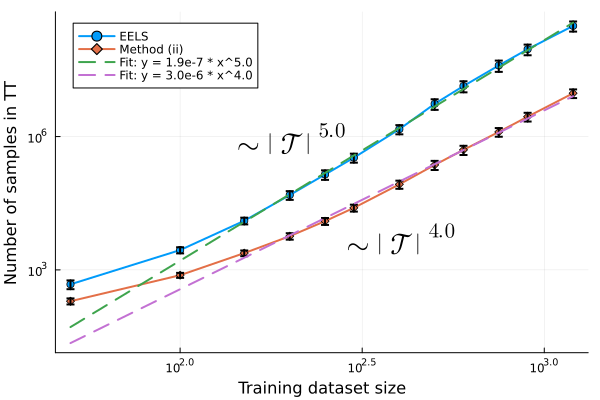

In [49]:
rs = load("../data/random_problems_n_50_m_5_r_1/res.jld2")["res_dict"]

fit_and_plot_num_samples(rs, num_skip=2)

annotate!(
    200, 900000,
    text(L"\sim \left| \mathcal{T} \right|^{5.0}", 20, rotation=0)
)

annotate!(
    400, 5000,
    text(L"\sim \left| \mathcal{T} \right|^{4.0}", 20, rotation=0)
)

In [ ]:
savefig("pictures/Num_samples_r1.png")

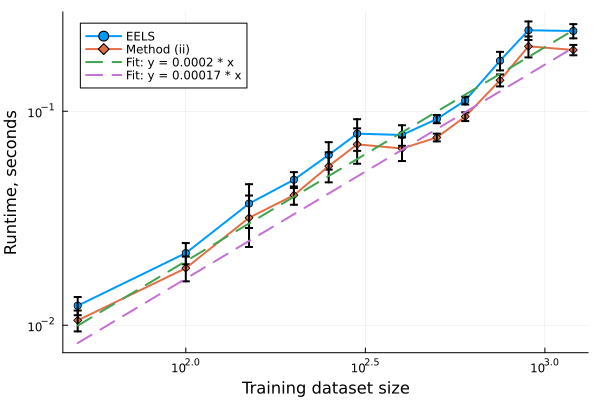

In [51]:
fit_and_plot_time(rs, num_skip=0)

In [ ]:
savefig("pictures/Time_r1.png")